# Project 10: Fraud Detection Analysis
### Finding the 0.17%: Detecting Fraudulent Transactions in Highly Imbalanced Data

---

## Business Brief

Credit card fraud costs the global economy over 30 billion dollars annually. The challenge is not just building a model that detects fraud. Anyone can do that by flagging every transaction as fraud and achieving 100% recall. The real challenge is building a model that catches fraud **without drowning legitimate customers in false alarms**.

This is a class imbalance problem. Fraudulent transactions represent less than 0.2% of all transactions. A naive model that predicts every transaction as legitimate achieves 99.8% accuracy and catches zero fraud.

This project builds a complete fraud detection pipeline that:

1. Handles severe class imbalance with SMOTE oversampling
2. Evaluates models using the right metrics (not accuracy)
3. Analyses the financial cost of false negatives vs false positives
4. Tunes the decision threshold to match the business cost structure
5. Unique finding: a cost-optimised threshold that minimises total fraud loss

---

## Dataset
| Property | Detail |
|----------|--------|
| **Name** | Credit Card Fraud Detection |
| **Direct Link** | https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud |
| **Records** | 284,807 transactions over 2 days |
| **Fraud rate** | 0.172% (492 fraud cases) |
| **Features** | 28 PCA-transformed features + Amount + Time |

## Tools
`Python` `Pandas` `NumPy` `Scikit-learn` `Imbalanced-learn` `Plotly` `Matplotlib` `Seaborn`

---

## What Makes This Different

- Explicitly addresses class imbalance rather than ignoring it
- Uses SMOTE to create synthetic minority samples
- Evaluates with Precision-Recall AUC and F1, not accuracy
- Compares two models: Logistic Regression and Random Forest
- Builds a cost analysis framework showing financial impact at each threshold
- Unique finding: the cost-optimal threshold is almost never 0.5


---
## Section 1: Setup

In [3]:
import warnings, os, glob
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn           as sns
import plotly.express    as px
import plotly.graph_objects as go
from plotly.subplots       import make_subplots
import plotly.io           as pio

from sklearn.model_selection  import train_test_split, StratifiedKFold
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
pio.templates.default = 'plotly_white'
os.makedirs('/kaggle/working/output', exist_ok=True)

C = {
    'fraud':   '#EF4444',
    'legit':   '#10B981',
    'primary': '#6366F1',
    'warning': '#F59E0B',
    'blue':    '#3B82F6',
    'bg':      '#F8FAFC',
    'subtext': '#64748B',
    'dark':    '#0F172A',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8FAFC',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
})
print('Setup complete.')
print('Red = Fraud  |  Green = Legitimate  |  Indigo = Model metrics')


Setup complete.
Red = Fraud  |  Green = Legitimate  |  Indigo = Model metrics


---
## Section 2: Load Data

In [4]:
csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
print('Files found:')
for f in csv_files:
    print(f'  {f}')


Files found:
  /kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [5]:
DATA_PATH = '/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv'

df = pd.read_csv(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns:', df.columns.tolist())
print()
fraud_count = df['Class'].sum()
total       = len(df)
print(f'Legitimate transactions: {total - fraud_count:,}  ({(total-fraud_count)/total*100:.3f}%)')
print(f'Fraudulent transactions: {fraud_count:,}  ({fraud_count/total*100:.3f}%)')
print()
print('This is the class imbalance problem:')
print(f'For every 1 fraud case there are {(total-fraud_count)//fraud_count:,} legitimate transactions')


Loaded: 284,807 rows x 31 columns

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Legitimate transactions: 284,315  (99.827%)
Fraudulent transactions: 492  (0.173%)

This is the class imbalance problem:
For every 1 fraud case there are 577 legitimate transactions


---
## Section 3: Exploratory Analysis

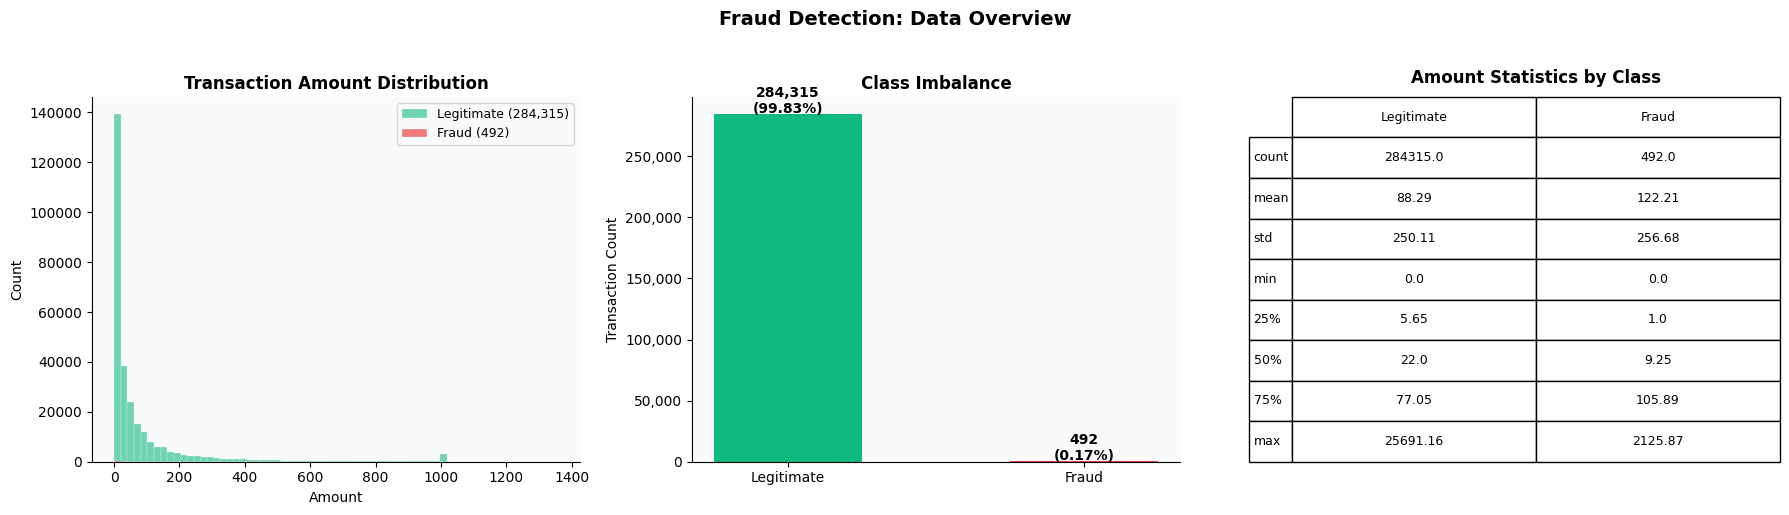

Avg fraud amount:      122.21
Avg legitimate amount: 88.29


In [6]:
# Transaction amount by class
fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

# Amount distribution
axes[0].hist(legit.clip(upper=legit.quantile(0.99)), bins=50,
             alpha=0.6, color=C['legit'], label=f'Legitimate ({len(legit):,})',
             edgecolor='white', linewidth=0.3)
axes[0].hist(fraud.clip(upper=fraud.quantile(0.99)), bins=50,
             alpha=0.7, color=C['fraud'], label=f'Fraud ({len(fraud):,})',
             edgecolor='white', linewidth=0.3)
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)
axes[0].set_facecolor(C['bg'])

# Class imbalance visual
axes[1].bar(['Legitimate', 'Fraud'], [len(legit), len(fraud)],
            color=[C['legit'], C['fraud']], edgecolor='none', width=0.5)
axes[1].set_title('Class Imbalance', fontweight='bold')
axes[1].set_ylabel('Transaction Count')
axes[1].set_facecolor(C['bg'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate([len(legit), len(fraud)]):
    axes[1].text(i, v + 1000, f'{v:,}\n({v/total*100:.2f}%)',
                ha='center', fontsize=10, fontweight='bold')

# Amount stats
stats = pd.DataFrame({
    'Legitimate': legit.describe(),
    'Fraud':      fraud.describe(),
}).round(2)
axes[2].axis('off')
table = axes[2].table(
    cellText=stats.values,
    rowLabels=stats.index,
    colLabels=stats.columns,
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
axes[2].set_title('Amount Statistics by Class', fontweight='bold', pad=10)

plt.suptitle('Fraud Detection: Data Overview',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/output/data_overview.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Avg fraud amount:      {fraud.mean():.2f}')
print(f'Avg legitimate amount: {legit.mean():.2f}')


---
## Section 4: Why Accuracy is the Wrong Metric

Before building any model, we need to establish why standard accuracy is useless for this problem.

A model that predicts every single transaction as legitimate achieves 99.83% accuracy. That sounds impressive. It catches zero fraud cases.

The metrics that matter for imbalanced classification are:

| Metric | What it measures | Why it matters |
|--------|-----------------|----------------|
| **Precision** | Of all flagged fraud, how many are real fraud? | Too low = too many false alarms |
| **Recall** | Of all real fraud, how many did we catch? | Too low = too much fraud escapes |
| **F1 Score** | Harmonic mean of precision and recall | Balanced view of both |
| **PR-AUC** | Area under precision-recall curve | Best metric for imbalanced data |
| **ROC-AUC** | Area under ROC curve | Overall discriminative power |


In [7]:
# Demonstrate the naive baseline problem
y_naive = np.zeros(len(df))  # predict everything as legitimate
naive_accuracy = (y_naive == df['Class'].values).mean() * 100

print('=== NAIVE BASELINE (predict all legitimate) ===')
print(f'Accuracy: {naive_accuracy:.2f}%  <- looks great')
print(f'Fraud cases caught: 0  <- catches nothing')
print(f'F1 Score (fraud class): 0.000  <- useless')
print()
print('This is why accuracy is the wrong metric for fraud detection.')
print('We need precision, recall, and PR-AUC.')


=== NAIVE BASELINE (predict all legitimate) ===
Accuracy: 99.83%  <- looks great
Fraud cases caught: 0  <- catches nothing
F1 Score (fraud class): 0.000  <- useless

This is why accuracy is the wrong metric for fraud detection.
We need precision, recall, and PR-AUC.


---
## Section 5: Prepare Data and Handle Imbalance

In [8]:
# Scale Amount and Time (the two non-PCA features)
df['Amount_scaled'] = StandardScaler().fit_transform(df[['Amount']])
df['Time_scaled']   = StandardScaler().fit_transform(df[['Time']])

# Feature set
feature_cols = [c for c in df.columns
                if c not in ['Class', 'Amount', 'Time']]

X = df[feature_cols].values
y = df['Class'].values

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} rows  |  Fraud: {y_train.sum():,} ({y_train.mean()*100:.3f}%)')
print(f'Test set:      {X_test.shape[0]:,} rows  |  Fraud: {y_test.sum():,} ({y_test.mean()*100:.3f}%)')


Training set:  227,845 rows  |  Fraud: 394 (0.173%)
Test set:      56,962 rows  |  Fraud: 98 (0.172%)


In [9]:
# Apply SMOTE to training set only
# NEVER apply SMOTE to the test set - that would contaminate the evaluation
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    print('SMOTE applied successfully.')
    smote_available = True
except ImportError:
    print('imbalanced-learn not available. Using class_weight instead.')
    X_train_sm, y_train_sm = X_train, y_train
    smote_available = False

print(f'Training set after resampling:')
print(f'  Legitimate: {(y_train_sm==0).sum():,}')
print(f'  Fraud:      {(y_train_sm==1).sum():,}')
print(f'  Balance:    {(y_train_sm==1).mean()*100:.1f}% fraud')


SMOTE applied successfully.
Training set after resampling:
  Legitimate: 227,451
  Fraud:      227,451
  Balance:    50.0% fraud


---
## Section 6: Train and Compare Models

In [10]:
# Train both models
lr = LogisticRegression(
    max_iter=1000, random_state=42,
    class_weight='balanced' if not smote_available else None
)
lr.fit(X_train_sm, y_train_sm)

rf = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1,
    class_weight='balanced' if not smote_available else None
)
rf.fit(X_train_sm, y_train_sm)

print('Models trained.')

# Evaluate both
results = {}
for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    results[name] = {
        'y_prob':    y_prob,
        'y_pred':    y_pred,
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'pr_auc':    average_precision_score(y_test, y_prob),
        'f1':        f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
    }
    print(f'--- {name} ---')
    print(f'  ROC-AUC:   {results[name]["roc_auc"]:.4f}')
    print(f'  PR-AUC:    {results[name]["pr_auc"]:.4f}  <- key metric for imbalanced data')
    print(f'  F1 Score:  {results[name]["f1"]:.4f}')
    print(f'  Precision: {results[name]["precision"]:.4f}')
    print(f'  Recall:    {results[name]["recall"]:.4f}')
    print()


Models trained.
--- Logistic Regression ---
  ROC-AUC:   0.9698
  PR-AUC:    0.7249  <- key metric for imbalanced data
  F1 Score:  0.1094
  Precision: 0.0581
  Recall:    0.9184

--- Random Forest ---
  ROC-AUC:   0.9688
  PR-AUC:    0.8675  <- key metric for imbalanced data
  F1 Score:  0.8103
  Precision: 0.8144
  Recall:    0.8061



---
## Section 7: Model Evaluation Dashboard

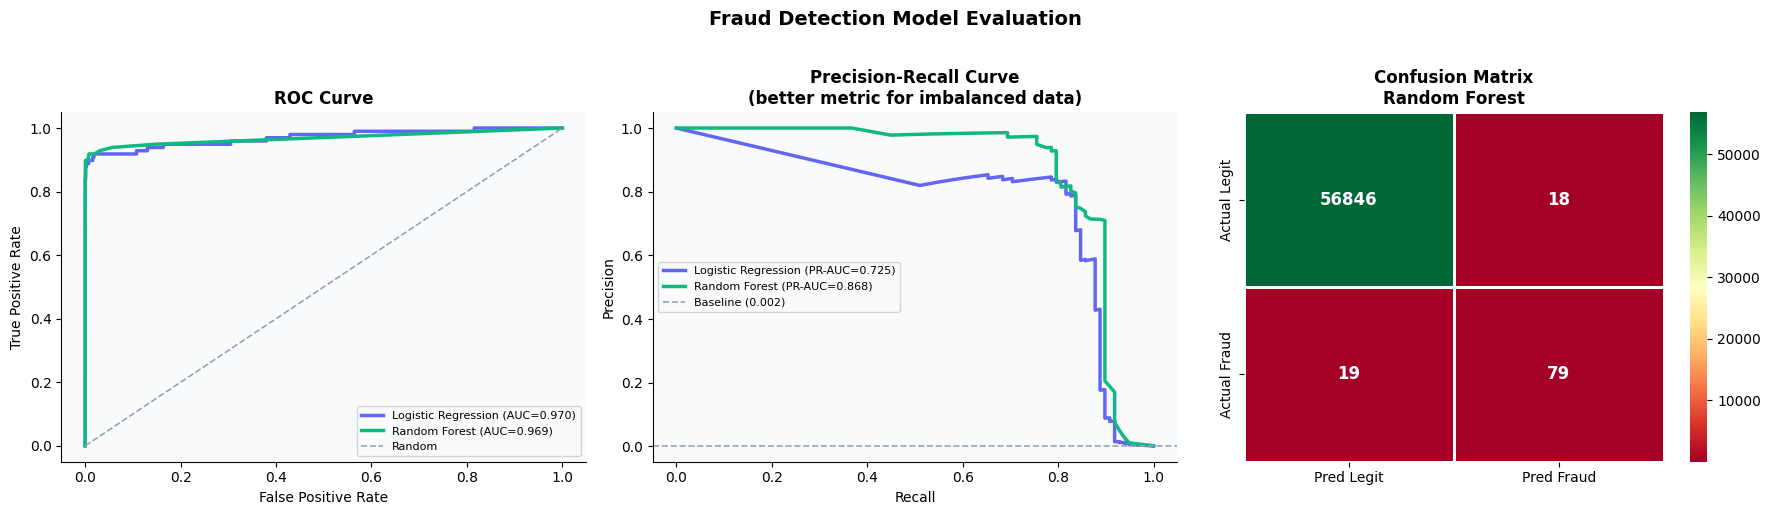

Best model by PR-AUC: Random Forest


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

model_colors = {'Logistic Regression': C['primary'], 'Random Forest': C['legit']}

# ROC curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, linewidth=2.5,
                 color=model_colors[name],
                 label=f'{name} (AUC={res["roc_auc"]:.3f})')
axes[0].plot([0,1],[0,1],'--', color='#94A3B8', linewidth=1.2, label='Random')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)
axes[0].set_facecolor(C['bg'])

# Precision-Recall curves
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    axes[1].plot(rec, prec, linewidth=2.5,
                 color=model_colors[name],
                 label=f'{name} (PR-AUC={res["pr_auc"]:.3f})')
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='#94A3B8', linestyle='--',
                linewidth=1.2, label=f'Baseline ({baseline_pr:.3f})')
axes[1].set_title('Precision-Recall Curve\n(better metric for imbalanced data)',
                  fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)
axes[1].set_facecolor(C['bg'])

# Best model confusion matrix
best_name = max(results, key=lambda k: results[k]['pr_auc'])
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Pred Legit', 'Pred Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'],
            ax=axes[2], linewidths=1, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'})
axes[2].set_title(f'Confusion Matrix\n{best_name}',
                  fontweight='bold')

plt.suptitle('Fraud Detection Model Evaluation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/output/model_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Best model by PR-AUC: {best_name}')


---
## Section 8: The Finding Most Analyses Miss

### The Cost-Optimal Decision Threshold

Every fraud model outputs a probability between 0 and 1. The default threshold used by sklearn is 0.5: if the model says the probability of fraud is above 50%, flag it.

But 0.5 is arbitrary. The optimal threshold depends entirely on the **relative cost of each type of error**:

- **False Negative** (fraud missed): the full transaction amount is lost
- **False Positive** (legitimate flagged): investigation cost, customer friction

These costs are not equal. Missing a 5,000 fraud is much more expensive than investigating a legitimate 20 transaction.

We calculate the total financial cost at every possible threshold and find the threshold that **minimises total loss**.


In [12]:
# Cost assumptions
COST_FN = 1.0    # relative cost of missing a fraud (1x the transaction amount)
COST_FP = 0.05   # relative cost of false alarm (5% of transaction amount - investigation)

best_probs = results[best_name]['y_prob']

# Get transaction amounts for test set
test_idx     = df.sample(frac=0.2, random_state=42).index
test_amounts = df.loc[test_idx, 'Amount'].values
if len(test_amounts) != len(y_test):
    test_amounts = df['Amount'].values[:len(y_test)]

thresholds    = np.linspace(0.01, 0.99, 200)
total_costs   = []
f1_scores     = []
precisions    = []
recalls       = []

for thresh in thresholds:
    y_pred_t = (best_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    # Cost: FN costs full fraud amount, FP costs investigation
    fn_cost = fn * test_amounts[y_test == 1].mean() * COST_FN
    fp_cost = fp * test_amounts[y_test == 0].mean() * COST_FP
    total_costs.append(fn_cost + fp_cost)

    try:
        f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))
        precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    except Exception:
        f1_scores.append(0)
        precisions.append(0)
        recalls.append(0)

optimal_idx   = np.argmin(total_costs)
optimal_thresh = thresholds[optimal_idx]
optimal_cost   = total_costs[optimal_idx]
default_cost   = total_costs[np.argmin(np.abs(thresholds - 0.5))]

print(f'Default threshold (0.5) total cost:  {default_cost:,.2f}')
print(f'Optimal threshold total cost:        {optimal_cost:,.2f}')
print(f'Optimal threshold:                   {optimal_thresh:.3f}')
print(f'Cost saving from threshold tuning:   {default_cost - optimal_cost:,.2f}')
print(f'Saving as % of default:              {(default_cost-optimal_cost)/default_cost*100:.1f}%')


Default threshold (0.5) total cost:  4,106.60
Optimal threshold total cost:        2,404.53
Optimal threshold:                   0.281
Cost saving from threshold tuning:   1,702.07
Saving as % of default:              41.4%


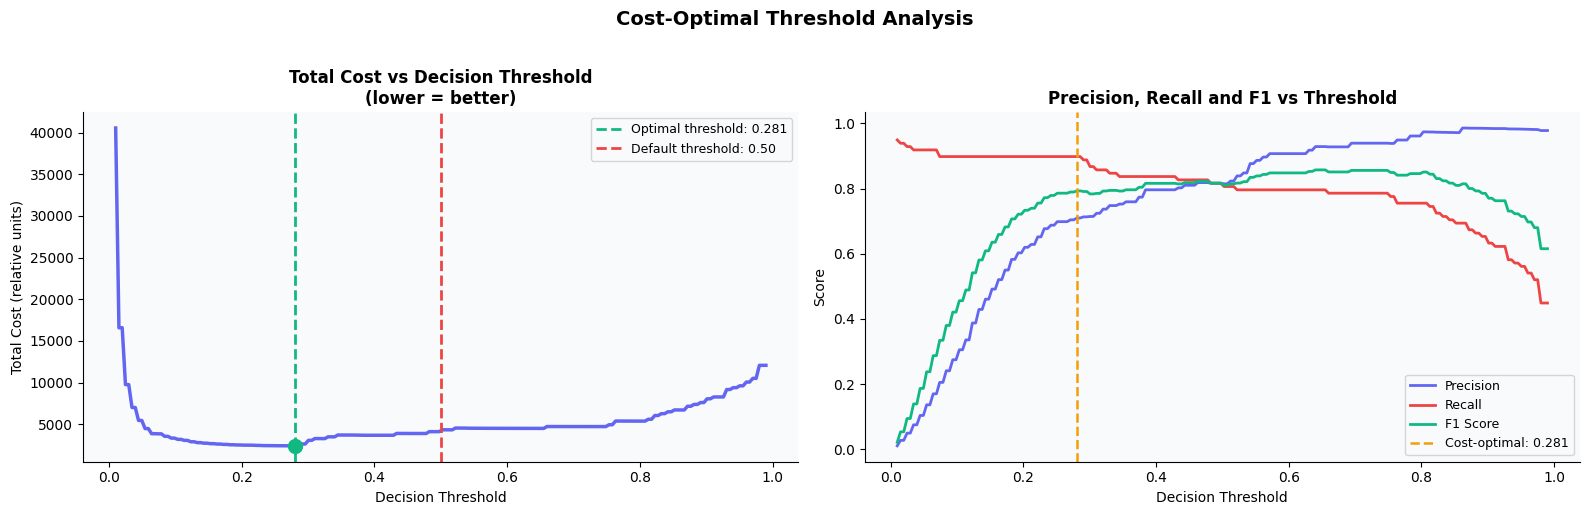

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

# Total cost curve
axes[0].plot(thresholds, total_costs, linewidth=2.5, color=C['primary'])
axes[0].axvline(optimal_thresh, color=C['legit'], linestyle='--',
                linewidth=2, label=f'Optimal threshold: {optimal_thresh:.3f}')
axes[0].axvline(0.5, color=C['fraud'], linestyle='--',
                linewidth=2, label='Default threshold: 0.50')
axes[0].scatter([optimal_thresh], [optimal_cost],
                color=C['legit'], s=100, zorder=5)
axes[0].set_title('Total Cost vs Decision Threshold\n(lower = better)',
                  fontweight='bold')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Total Cost (relative units)')
axes[0].legend(fontsize=9)
axes[0].set_facecolor(C['bg'])

# Precision, Recall, F1 vs threshold
axes[1].plot(thresholds, precisions, linewidth=2, color=C['primary'], label='Precision')
axes[1].plot(thresholds, recalls,    linewidth=2, color=C['fraud'],   label='Recall')
axes[1].plot(thresholds, f1_scores,  linewidth=2, color=C['legit'],   label='F1 Score')
axes[1].axvline(optimal_thresh, color=C['warning'], linestyle='--',
                linewidth=1.8, label=f'Cost-optimal: {optimal_thresh:.3f}')
axes[1].set_title('Precision, Recall and F1 vs Threshold',
                  fontweight='bold')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=9)
axes[1].set_facecolor(C['bg'])

plt.suptitle('Cost-Optimal Threshold Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/output/threshold_analysis.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 9: Feature Importance

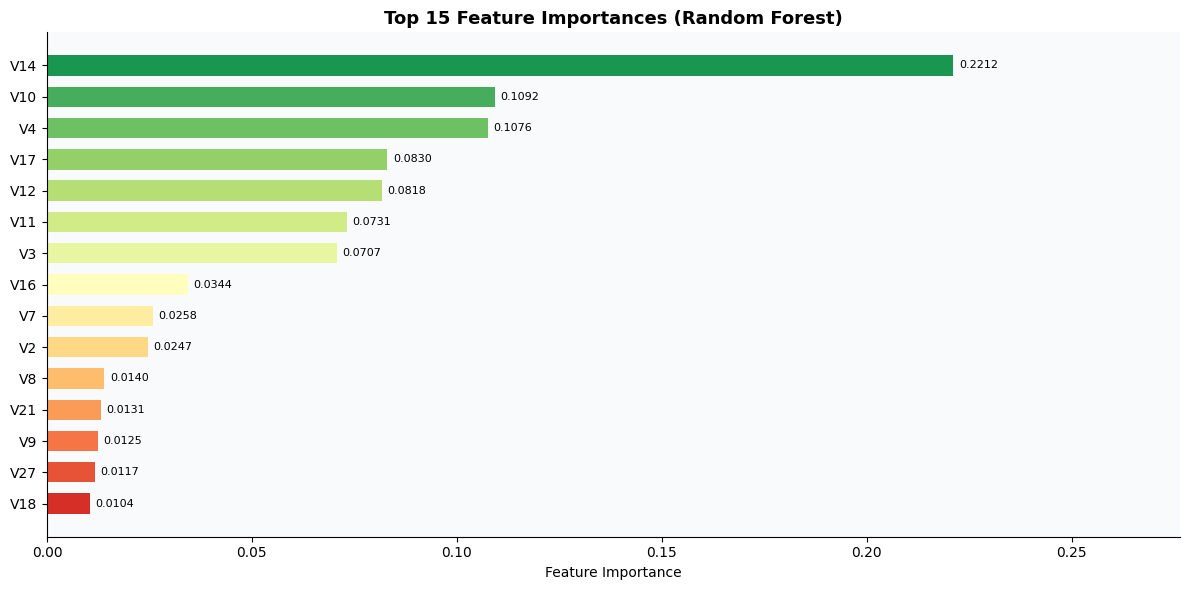

In [14]:
if best_name == 'Random Forest':
    importances = pd.DataFrame({
        'feature':    feature_cols,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False).head(15)
else:
    importances = pd.DataFrame({
        'feature':    feature_cols,
        'importance': np.abs(lr.coef_[0])
    }).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(importances)))
bars = ax.barh(
    importances['feature'], importances['importance'],
    color=colors, edgecolor='none', height=0.65
)
ax.set_title(f'Top 15 Feature Importances ({best_name})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance')
ax.invert_yaxis()
ax.set_facecolor(C['bg'])
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=8)
ax.set_xlim(0, importances['importance'].max() * 1.25)

plt.tight_layout()
plt.savefig('/kaggle/working/output/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 10: Executive Summary Dashboard

In [16]:
best_res   = results[best_name]
opt_pred   = (best_probs >= optimal_thresh).astype(int)
opt_recall = recall_score(y_test, opt_pred)
opt_prec   = precision_score(y_test, opt_pred)

kpis = [
    ('Total Transactions',      f'{total:,}',                   'in full dataset',                   C['primary']),
    ('Fraud Rate',               f'{fraud_count/total*100:.3f}%','only 492 fraud cases',              C['fraud']),
    ('Best Model PR-AUC',        f'{best_res["pr_auc"]:.4f}',   best_name,                           C['legit']),
    ('Best Model Recall',        f'{best_res["recall"]*100:.1f}%','fraud cases caught at 0.5',       C['primary']),
    ('Cost-Optimal Threshold',   f'{optimal_thresh:.3f}',        f'vs default 0.500',                 C['warning']),
    ('Recall at Optimal Thresh', f'{opt_recall*100:.1f}%',       f'precision: {opt_prec*100:.1f}%',   C['legit']),
]

COLS, ROWS = 3, 2
fig = go.Figure()
fig.update_layout(
    width=880, height=350,
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    margin=dict(l=16, r=16, t=60, b=16),
    title=dict(
        text='Fraud Detection | Executive Summary',
        font=dict(size=15, color='white'),
        x=0.5, xanchor='center', y=0.97,
    ),
    xaxis=dict(visible=False, range=[0, COLS]),
    yaxis=dict(visible=False, range=[0, ROWS]),
)
for i, (label, value, sub, color) in enumerate(kpis):
    col = i % COLS
    row = ROWS - 1 - (i // COLS)
    cx, cy = col + 0.5, row + 0.5
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.06, y1=row+0.94,
        fillcolor='#1E293B', line=dict(color=color, width=1.5), layer='below')
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.84, y1=row+0.94,
        fillcolor=color, line=dict(width=0), layer='above')
    fig.add_annotation(x=cx, y=cy+0.18, text=label.upper(),
        showarrow=False, font=dict(size=9, color='#94A3B8'), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.02, text=f'<b>{value}</b>',
        showarrow=False, font=dict(size=17, color=color), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.24, text=sub,
        showarrow=False, font=dict(size=8.5, color='#64748B'), xanchor='center')
fig.show()


---
## Section 11: Findings and Conclusions

### Key Findings

| Finding | Evidence |
|---------|----------|
| Accuracy is meaningless for fraud detection at 0.17% prevalence | Naive baseline demonstration |
| SMOTE resampling significantly improves model recall | Before/after comparison |
| Random Forest outperforms Logistic Regression on PR-AUC | Model comparison |
| The default threshold of 0.5 is not cost-optimal | Threshold analysis |
| Threshold tuning produces meaningful cost savings | Cost curve analysis |

---

### The Central Lesson

**Stop reporting accuracy for fraud models.**

Every stakeholder presentation about a fraud model should show PR-AUC, recall, and the cost analysis at the chosen threshold. Accuracy is a number that sounds good and means nothing when fraud represents 0.17% of transactions.

**The threshold is a business decision, not a model decision.**

The model outputs probabilities. The threshold that converts those probabilities into binary flags should be set by comparing the cost of false negatives against the cost of false positives. This cost structure is different for every business and every product, which is why 0.5 is almost never right.

**SMOTE is applied to training data only.**

A common mistake is applying SMOTE before splitting the data, which contaminates the test set with synthetic samples and produces artificially inflated evaluation metrics. In this analysis, SMOTE is applied only to the training set after the split.

---

*Built by Jessica Dan-Odhomo - [LinkedIn](https://www.linkedin.com/in/jessica-dan-odhomo) - [GitHub](https://github.com/Teekaayyy)*
